<a href="https://colab.research.google.com/github/HaileyHal/Predicting-Song-Popularity-on-Spotify-Using-Multiple-Linear-Regression/blob/main/DA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DA 2**


## Business Problem

How can we help our client (an upcoming songwriter and musician) predict how popular their upcoming released songs will be in the current music scene?

## Introduction to dataset:

Our response variable is the popularity score (in points). The categorical variables are playlist genre and time signature. The independent/continutous variables are energy, tempo, loudness, danceability, liveness, valence, duration, and speechiness.

There are 1686 rows. We have one response variable, three categorical variables (that we are using) with 8 parameters for playlist_genre and 3 parameters for time_signature and 11 parameters for key. We also have 10 continuous variables. This is a total of 32 parameters, requiring 320 rows, so we have plenty to spare.

In [ ]:
!pip install skglm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
# Import libraries and data
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.graphics.factorplots import interaction_plot

from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, ElasticNet, ElasticNetCV, LinearRegression
from sklearn.model_selection import GridSearchCV
from skglm import GroupLasso


df = pd.read_csv('high_popularity_spotify_data.csv')
df.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [ ]:
# View columns
df.columns

Index(['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness',
       'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness',
       'track_popularity', 'track_href', 'uri', 'track_album_name',
       'playlist_name', 'analysis_url', 'track_id', 'track_name',
       'track_album_release_date', 'instrumentalness', 'track_album_id',
       'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre',
       'type', 'playlist_id'],
      dtype='object')

In [ ]:
# View information about dataset (variable types, etc)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    1686 non-null   float64
 1   tempo                     1686 non-null   float64
 2   danceability              1686 non-null   float64
 3   playlist_genre            1686 non-null   object 
 4   loudness                  1686 non-null   float64
 5   liveness                  1686 non-null   float64
 6   valence                   1686 non-null   float64
 7   track_artist              1686 non-null   object 
 8   time_signature            1686 non-null   int64  
 9   speechiness               1686 non-null   float64
 10  track_popularity          1686 non-null   int64  
 11  track_href                1686 non-null   object 
 12  uri                       1686 non-null   object 
 13  track_album_name          1685 non-null   object 
 14  playlist

In [ ]:
# View row with our singular null value
row_with_null = df[df['track_album_name'].isnull()]

print(row_with_null)

     energy    tempo  danceability playlist_genre  loudness  liveness  \
665   0.926  105.969         0.682          k-pop    -2.515      0.19   

     valence track_artist  time_signature  speechiness  ...  instrumentalness  \
665     0.86       NAYEON               4       0.0607  ...               0.0   

             track_album_id mode key duration_ms acousticness  \
665  5zQI9dFbS9TrhvC9clgjz7    0   3      162840       0.0404   

                         id playlist_subgenre            type  \
665  0V2passWyAXnON67kfAj7y            modern  audio_features   

                playlist_id  
665  1bNuDsel3P60p11Z7vfHMR  

[1 rows x 29 columns]


After investigating our dataset, this is NOT a null value. The track_album_name is literally NA, so when pandas saw that, it interpreted the value as null. We will simply replace it with 'NA' to fill that gap.

In [ ]:
# Put 'NA' back into the track_album_name for that row
# We can use fillna becuase there's only one null value
df = df.fillna('NA')

# Double check that there are no more null values
df.isnull().sum()

,0
energy,0
tempo,0
danceability,0
playlist_genre,0
loudness,0
liveness,0
valence,0
track_artist,0
time_signature,0
speechiness,0


In [ ]:
# View how many different categories are in the playlist_genre column
df['playlist_genre'].value_counts()

,count
playlist_genre,
pop,357
rock,235
hip-hop,227
latin,184
electronic,148
gaming,100
ambient,61
r&b,50
arabic,50


<Axes: xlabel='playlist_genre'>

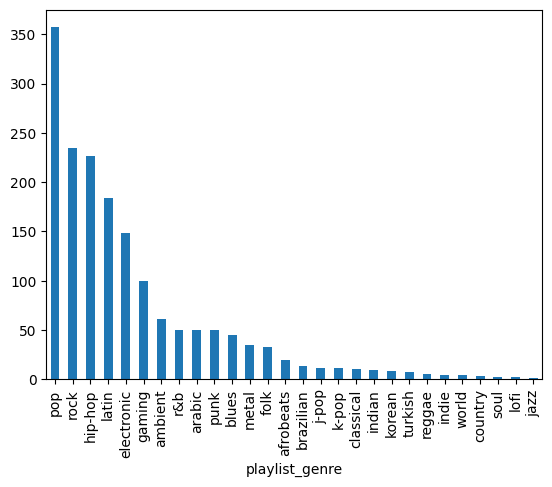

In [ ]:
# bar chart for playlist_genre
df['playlist_genre'].value_counts().plot(kind='bar')

In [ ]:
df['mode'].value_counts()  # Also categorial- minor or major song

,count
mode,
1,975
0,711


To narrow down the amount of genres we have, we plan to combine certain genres into the following buckets:
* International: Contains the arabic, turkish, korean, kpop, jpop, indian, brazilian, and afrobeats genres
* R&B Group: Contains R&B, soul, blues, and jazz
* Background Music: Contains ambient, lofi, and gaming
* Folk Group: Contains folk, indie, and country

In [ ]:
df['time_signature'].value_counts()

,count
time_signature,
4,1558
3,92
5,29
1,7


<Axes: xlabel='time_signature'>

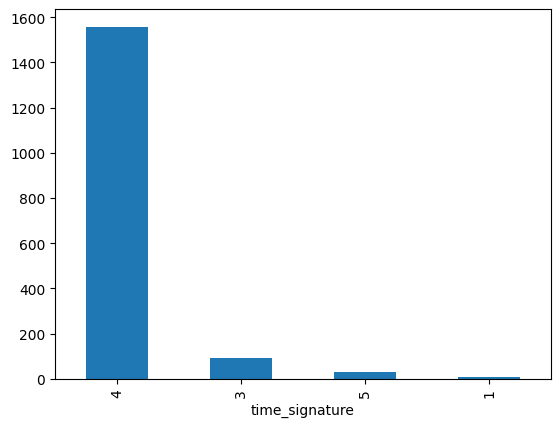

In [ ]:
# bar chart for time signature
df['time_signature'].value_counts().plot(kind='bar')

In [ ]:
df['key'].value_counts()

,count
key,
1,227
11,172
2,154
5,153
0,152
7,151
9,136
6,134
4,123


Even though our value counts for this aren't super even, time signature isn't something you can combine well, so we will leave it as it is.

### Inital Data Overview

In [ ]:
# Display first few rows of the dataset
df.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


Each row in this dataset represents a different song from the 100 most popular songs on spotify (from a recent time period). We have many columns in this dataset. We have a lot of columns that describe different qualities of songs, such as energy, tempo, danceability, loudness, liveness, valence, speechiness, instrumentalness, mode, key, acousticness, and probably more. We also have information for each track's artist, album, genre, when it was released, etc. There are a few other columns that are various identifiers.

In [ ]:
# keep only columns we want
df = df[['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness',
         'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness',
         'track_popularity', 'track_album_name',
         'instrumentalness', 'mode', 'key', 'duration_ms',
         'acousticness']]

In [ ]:
df.track_artist.value_counts()

,count
track_artist,
Bad Bunny,20
Linkin Park,14
Hozier,11
Sabrina Carpenter,11
Red Hot Chili Peppers,10
...,...
"will.i.am, Britney Spears",1
"Martin Garrix, Bebe Rexha",1
Axwell /\ Ingrosso,1


We were given feedback to include track artist but to look at the count of songs for each artist. We might have trouble with this, because there are many songs with featured artists that would be counted in the model as separate artists. It would be good to clean this to only include the first artist to try and consolidate.

In [ ]:
# Summary of the data- some of the categorical variables that are coded as integers are also in here- ignore those
df.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
count,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000
mean,0.667216,121.070938,0.650362,-6.704131,0.171579,0.525737,3.950178,0.100926,75.806050,0.041520,0.578292,5.338078,214562.125741,0.221220
std,0.184908,27.066029,0.157721,3.377068,0.123953,0.236113,0.326673,0.099748,6.032532,0.156556,0.493979,3.608208,58310.747929,0.250593
min,0.001610,49.305000,0.136000,-43.643000,0.021000,0.034800,1.000000,0.023200,68.000000,0.000000,0.000000,0.000000,61673.000000,0.000013
25%,0.551000,100.058750,0.543250,-7.950250,0.093400,0.339000,4.000000,0.037900,71.000000,0.000000,0.000000,2.000000,176607.750000,0.023050
50%,0.689000,120.001000,0.664500,-5.974500,0.121000,0.528000,4.000000,0.058100,75.000000,0.000006,1.000000,5.000000,211180.000000,0.124000
75%,0.807000,136.833500,0.769000,-4.687250,0.210000,0.720000,4.000000,0.118000,79.000000,0.000814,1.000000,8.000000,244993.250000,0.334750
max,0.990000,209.688000,0.979000,1.295000,0.950000,0.978000,5.000000,0.848000,100.000000,0.971000,1.000000,11.000000,547107.000000,0.995000


Our values look pretty reasonable, and now that we've dealt with one missing (though not actually missing) value, we don't really see any problems. Most of the variables that describe the song have a score 0-100, so the df.describe() looks good.

### Exploratory Visualizations

In [ ]:
# Get continuous columns from the data
columns = df[['track_popularity', 'energy', 'tempo', 'danceability','loudness','liveness',
             'valence', 'speechiness', 'instrumentalness', 'acousticness', 'duration_ms']]

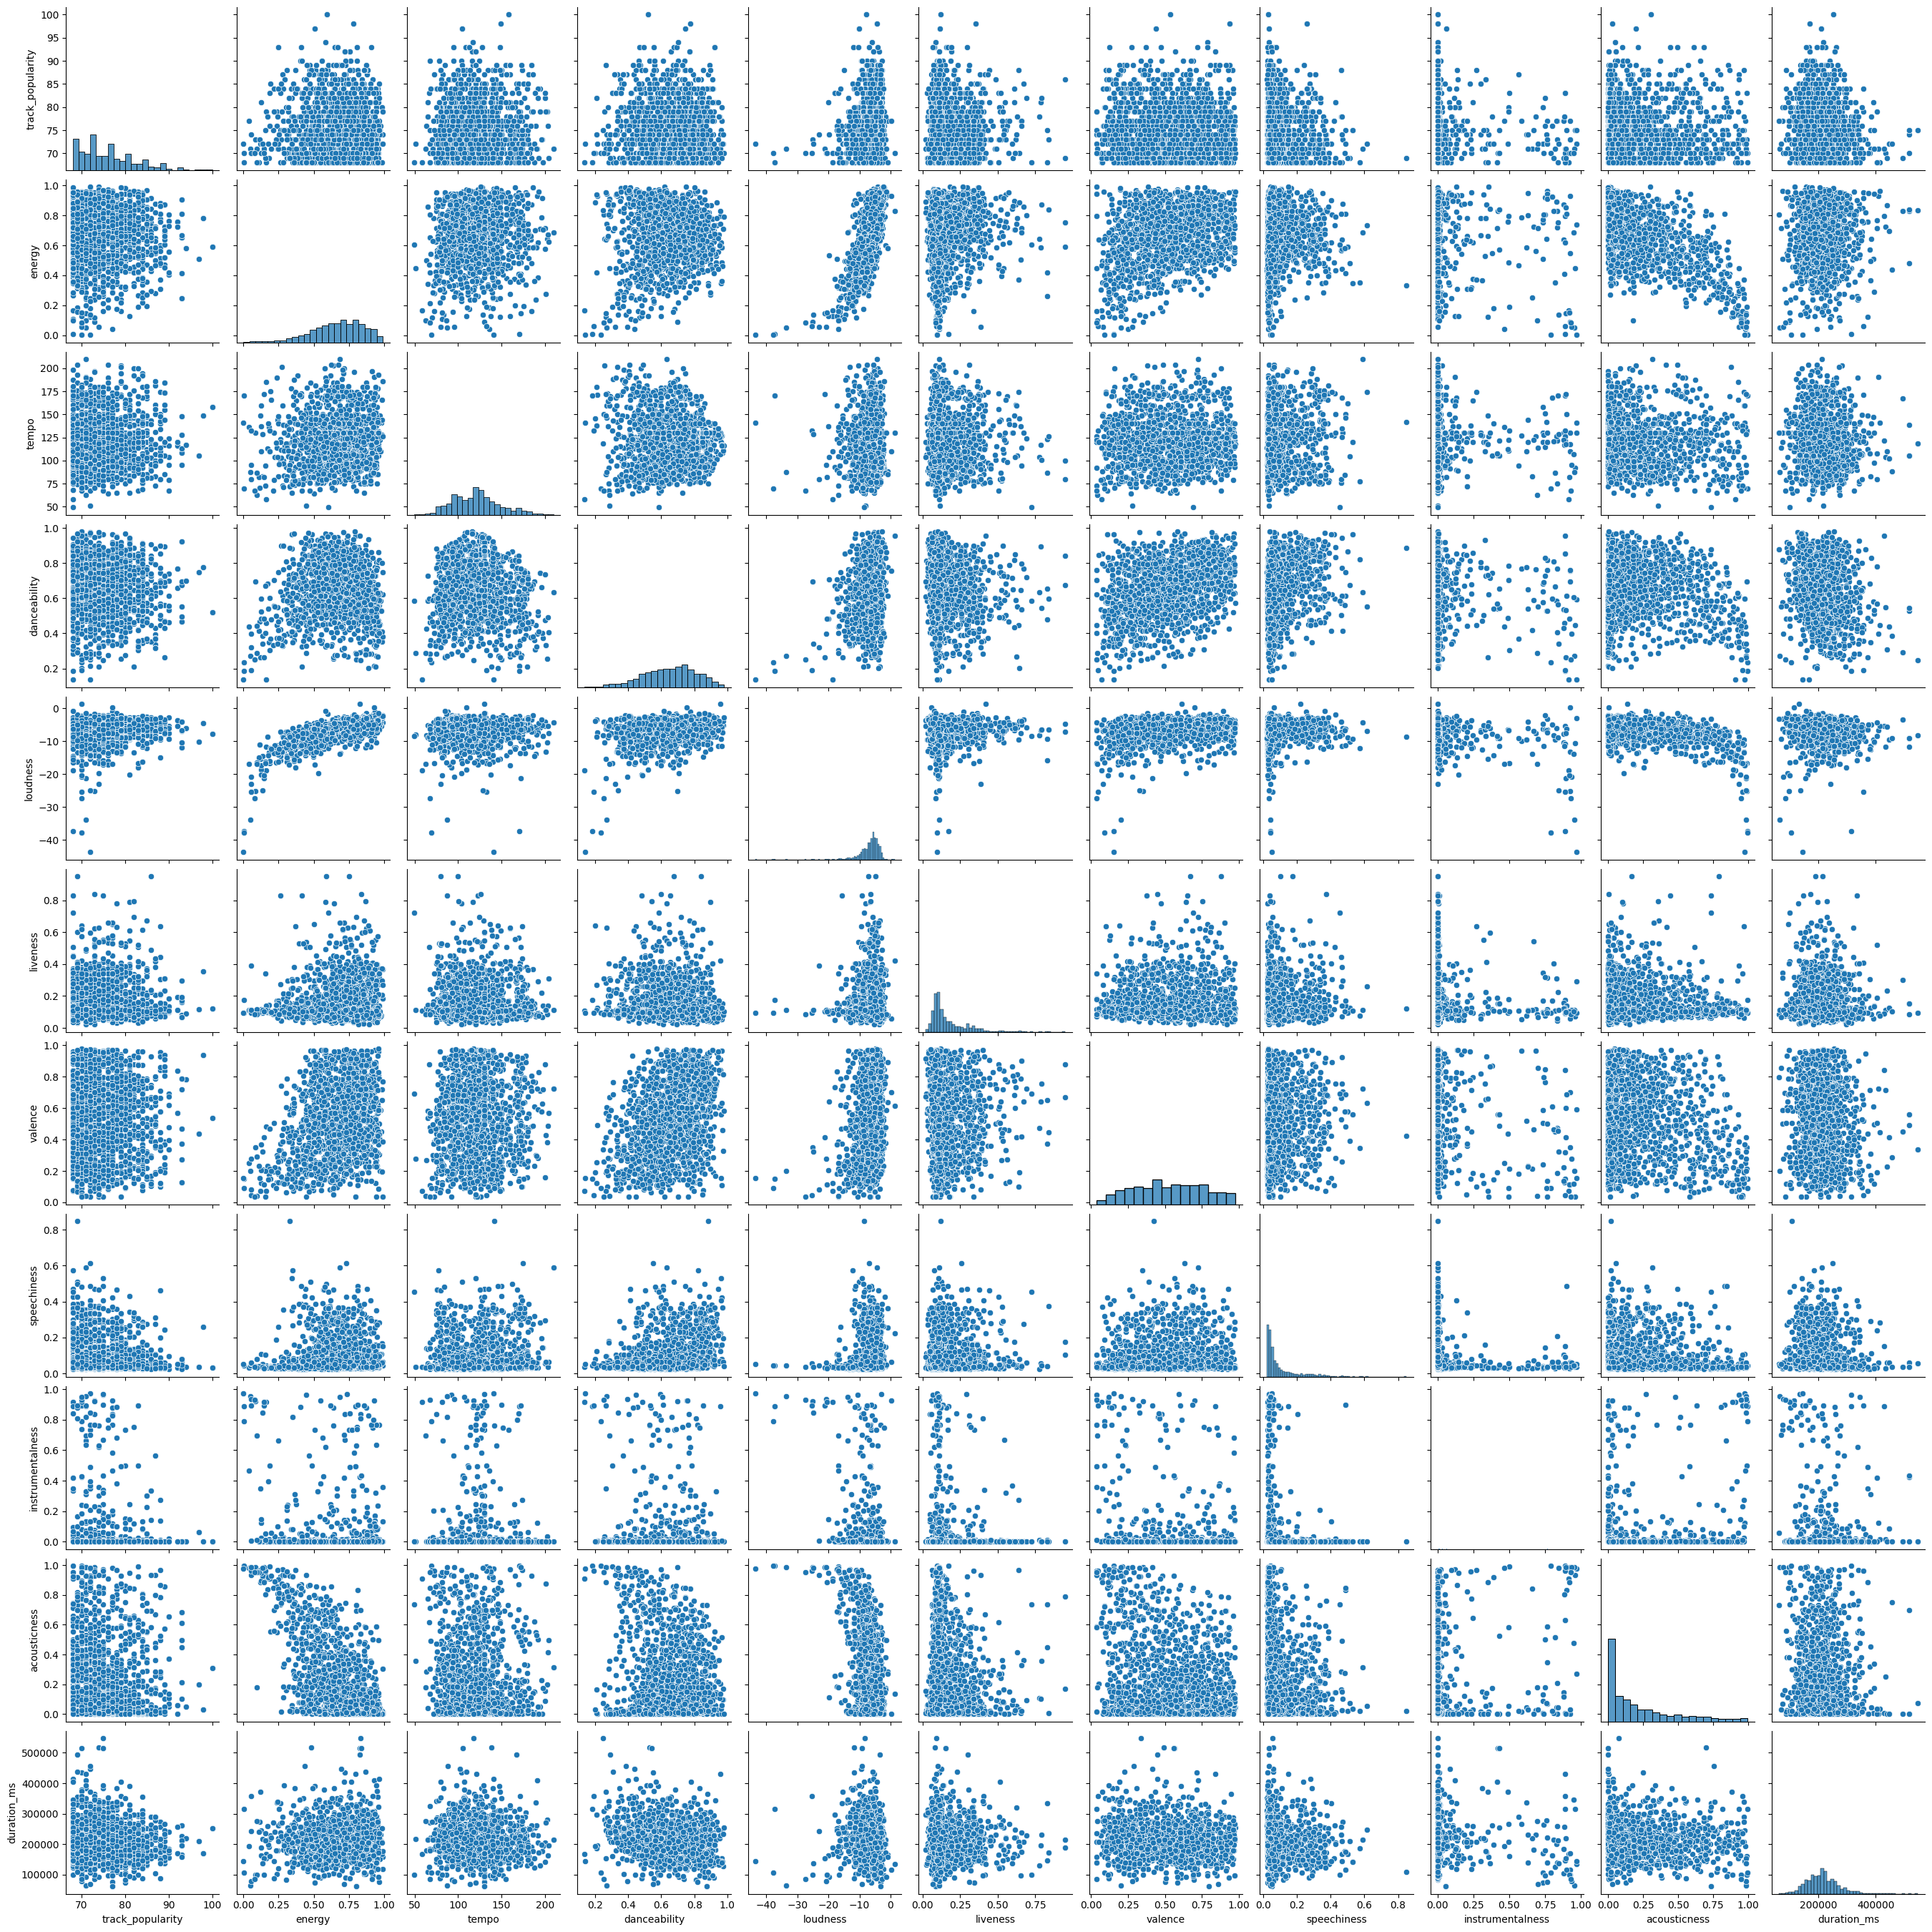

In [ ]:
# pairplot
sns.pairplot(columns)

Our scatterplot matrix is very interesting. It is great to see that none of the predictor variables seem to be strongly linearly correlated with each other- we'll have less issues with multicolinearity. Most of these have cloud-shaped patterns. We do have some predictor variables that have stranger shaped scatterplots, including loudness, liveness, and instrumentalness. The first two seem to have less variation in general (a thin curve on the distribution), and instrumentalness has a pattern that looks opposite of cloudlike, but still not linear.

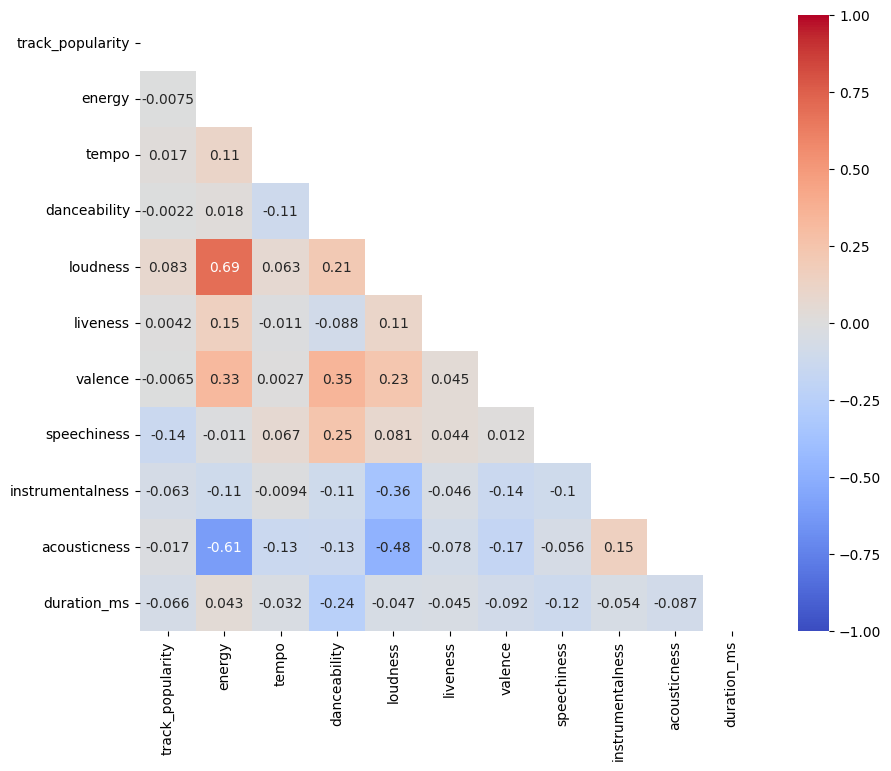

In [ ]:
# Color coded correlation matrix
plt.subplots(figsize=(10,8))
sns.heatmap(columns.corr(),
            cmap='coolwarm',
            annot=True,
            vmin=-1,
            vmax=1,
            mask=np.triu(columns.corr()))
plt.show()

The heatmap makes it easier for us to see which predictor variables may cause us multicolinearity issues. We can clearly see that the energy score and the loudness score are highly postivley correlated. Also, acousticness and energy are strongly negativley correlated. Logically, acousticness is also negativley correlated with loudness. While these are all fairly strongly correlated, there doesn't appear to be a strong multicolinearity issue, as all the correlation coefficients are less than the absolute value of .7. Because we're looking at how different song aspects impact track popularity, speechiness actually seems like the one that could impact that category the most, though, as it is negatively correlated with track popularity, but no correlations are super strong in that aspect.

### Transformations

Sorted playlist_genre into buckets to minimize the amount of genres in our model



In [ ]:
df['playlist_genre_clean'] = (
    df['playlist_genre']
    .str.lower()
    .str.strip()
)

# Group certain genres into other categories
international = {
    'arabic', 'turkish', 'korean', 'k-pop', 'j-pop',
    'indian', 'brazilian', 'afrobeats', 'world', 'latin',
    'reggae'
}

rnb_group = {'r&b', 'rnb', 'soul', 'blues', 'jazz'}

rock_group = {'rock', 'metal', 'punk'}

ambient_group = {'ambient', 'lofi', 'gaming'}

folk_group = {'folk', 'indie', 'country'}

In [ ]:
# Map genres to their new buckets
df.loc[df['playlist_genre_clean'].isin(international),
       'playlist_genre_clean'] = 'international'

df.loc[df['playlist_genre_clean'].isin(rnb_group),
       'playlist_genre_clean'] = 'r&b / soul / blues / jazz'

df.loc[df['playlist_genre_clean'].isin(rock_group),
       'playlist_genre_clean'] = 'rock / metal / punk'

df.loc[df['playlist_genre_clean'].isin(ambient_group),
       'playlist_genre_clean'] = 'background music'

df.loc[df['playlist_genre_clean'].isin(folk_group),
       'playlist_genre_clean'] = 'folk / indie / country'

In [ ]:
df['playlist_genre_clean'].value_counts()

,count
playlist_genre_clean,
pop,357
international,323
rock / metal / punk,320
hip-hop,227
background music,163
electronic,148
r&b / soul / blues / jazz,98
folk / indie / country,40
classical,10


With our new playlist genre column, pop still takes the lead, but international is also very high, with our rock/metal/punk cateogry right behind it. From there, the numbers drop off a lot, with hiphop being closest, and all other categories containing less than 200 songs.

In [ ]:
# consolidate track_artists
# split track_artist after , and only keep first part
df['track_artist_clean'] = df['track_artist'].str.split(',', n=1).str[0]
df['track_artist_clean'].value_counts()

,count
track_artist_clean,
Bad Bunny,39
Future,17
Lil Baby,16
Linkin Park,14
Drake,12
...,...
Werenoi,1
SativaMusic,1
Jungeli,1


In [ ]:
# dropping track_artist because the groups aren't large
df = df.drop(columns=['track_artist', 'track_artist_clean', 'playlist_genre', 'track_album_name'])

We stripped away the second artist on songs with multiple artists. This helped a lot, and consolidated about 300 rows. It is important to keep in mind though that we still have many artists with only one song. Without a way to feasibly clean it, and because it wasn't the focus of our project, we did decide to drop the columns regarding artist.

In [ ]:
# View value counts for time_signature
df['time_signature'].value_counts()

,count
time_signature,
4,1558
3,92
5,29
1,7


No transformation needs to happen for time_signature, however despite the fact that it uses numbers, we will consider this one a categorical variable, because the numbers represent time signatures such as 4/4, 3/4, etc. Most songs in the dataset (over 1500 songs) are in 4/4, while only about ~130 songs are in other time signatures.

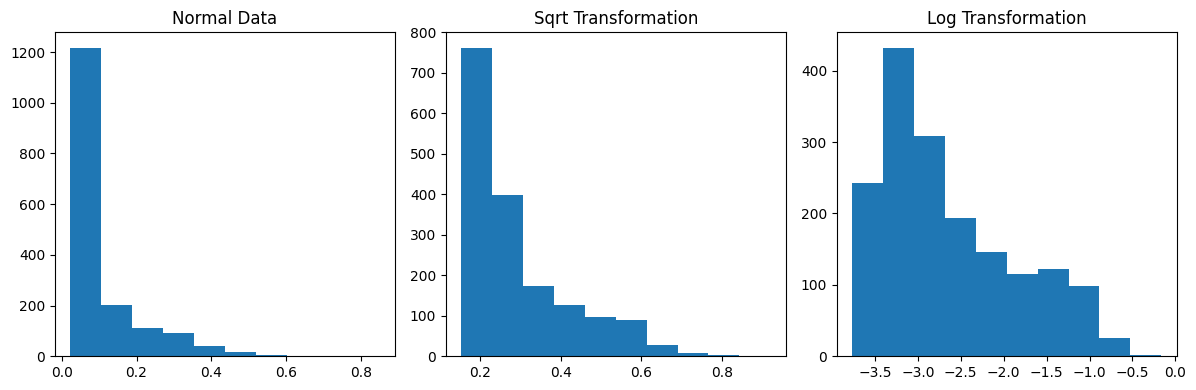

In [ ]:
# View histograms for speechiness, determine if we need a transformation
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4)) #

# Plot data1 and data2
axes[0].hist(df['speechiness'])
axes[0].set_title('Normal Data')
axes[1].hist(np.sqrt(df['speechiness']))
axes[1].set_title('Sqrt Transformation')
axes[2].hist(np.log(df['speechiness']))
axes[2].set_title('Log Transformation')

plt.tight_layout()
plt.show()

In [ ]:
# Log transform speechiness
df['log_speechiness'] = np.log(df['speechiness'])

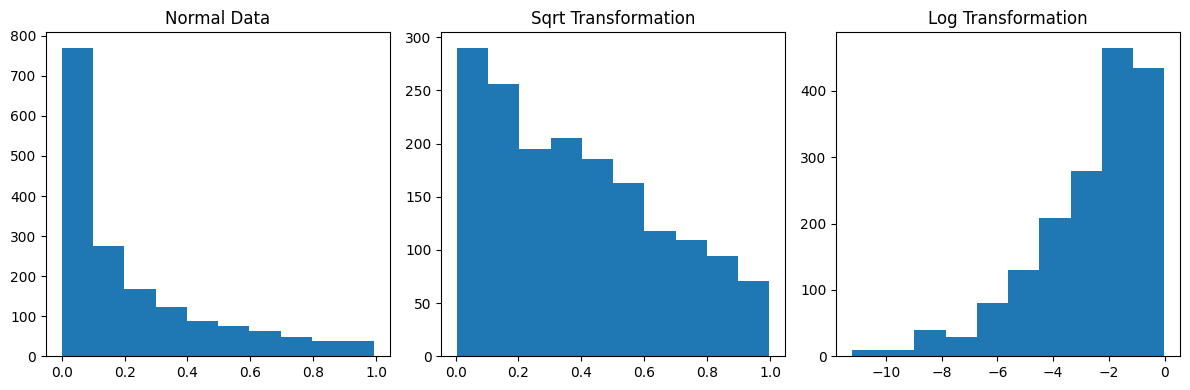

In [ ]:
# View histograms for acousticness, determine if we need a transformation
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4)) #

# Plot data1 and data2
axes[0].hist(df['acousticness'])
axes[0].set_title('Normal Data')
axes[1].hist(np.sqrt(df['acousticness']))
axes[1].set_title('Sqrt Transformation')
axes[2].hist(np.log(df['acousticness']))
axes[2].set_title('Log Transformation')

plt.tight_layout()
plt.show()

In [ ]:
# Square root transform acousticness
df['sqrt_acousticness'] = np.sqrt(df['acousticness'])

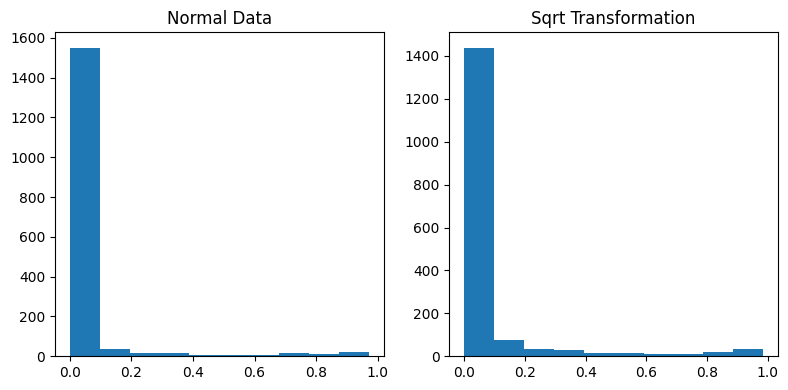

In [ ]:
# View histograms for instrumentalness, determine if we need a transformation
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4)) #

# Plot data1 and data2
axes[0].hist(df['instrumentalness'])
axes[0].set_title('Normal Data')
axes[1].hist(np.sqrt(df['instrumentalness']))
axes[1].set_title('Sqrt Transformation')
# Can't do log transformation without causing a value error

plt.tight_layout()
plt.show()

In [ ]:
# Sqrt transform instrumentalness
df['sqrt_instrumentalness'] = np.sqrt(df['instrumentalness'])

We have some pretty severe skewness in three of our columns: acousticness, speechiness, and instrumentalness.

Based on the graphs above, we decided to do a log transformation for speechiness and a square root transformation for acousticness, as those are the ones that look most normal.

Instrumentalness is a little bit different. Our square root transformation still looks skewed, however due to the nature of the data in the column, we cannot do a log transformation, because we get a value error. We will go forward with a square root transformation.

### Initial Hypotheses

We are likely not to run into any multicolinearity issues, as our highest correlated variable has a correlation coefficient of 0.69, and most other variables are far below that. From our EDA, it is not clear to see which predictor variables are likely to be most important when modeling song popularity. It is mildly concerning at this stage to see weak correlations between track popularity and our predictor variables, but we will trust the process as we go along.

# **DA2.3 - Initial Model Fit and Assumptions**

Initial Model Fit:

In [ ]:
df.columns

Index(['energy', 'tempo', 'danceability', 'loudness', 'liveness', 'valence',
       'time_signature', 'speechiness', 'track_popularity', 'instrumentalness',
       'mode', 'key', 'duration_ms', 'acousticness', 'playlist_genre_clean',
       'log_speechiness', 'sqrt_acousticness', 'sqrt_instrumentalness'],
      dtype='object')

In [ ]:
# dummy coding genre and time_signature
df_dummy = pd.get_dummies(df,
                          columns = ['playlist_genre_clean', 'time_signature', 'key'],
                          dtype = int, # Setting the type as Int for the new dummy cols
                          drop_first = True) # Background_music for genre becomes default, 1 for time_sig becomes default
# Drop original versions of transformed columns
df_dummy = df_dummy.drop(columns=['speechiness', 'instrumentalness','acousticness'])

df_dummy.head()

,energy,tempo,danceability,loudness,liveness,valence,track_popularity,mode,duration_ms,log_speechiness,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,0.592,157.969,0.521,-7.777,0.122,0.535,100,0,251668,-3.493313,...,0,0,0,0,1,0,0,0,0,0
1,0.507,104.978,0.747,-10.171,0.117,0.438,97,1,210373,-3.329807,...,1,0,0,0,0,0,0,0,0,0
2,0.808,108.548,0.554,-4.169,0.159,0.372,93,1,166300,-3.302257,...,0,0,0,0,0,0,0,0,0,0
3,0.910,112.966,0.670,-4.070,0.304,0.786,81,0,157280,-2.758291,...,0,0,0,0,0,0,0,0,0,0
4,0.783,149.027,0.777,-4.477,0.355,0.939,98,0,169917,-1.347074,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Fit model
y = df_dummy['track_popularity']
X = df_dummy.drop('track_popularity', axis=1)
X = sm.add_constant(X)  # making sure intercept is included
model = sm.OLS(y, X)
results = model.fit()

df['residuals'] = results.resid
df['fitted_vals'] = results.fittedvalues
df.head()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       track_popularity   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     14.20
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           7.27e-68
Time:                        05:12:03   Log-Likelihood:                -5211.4
No. Observations:                1686   AIC:                         1.049e+04
Df Residuals:                    1652   BIC:                         1.068e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

Diagnostics and Assumptions




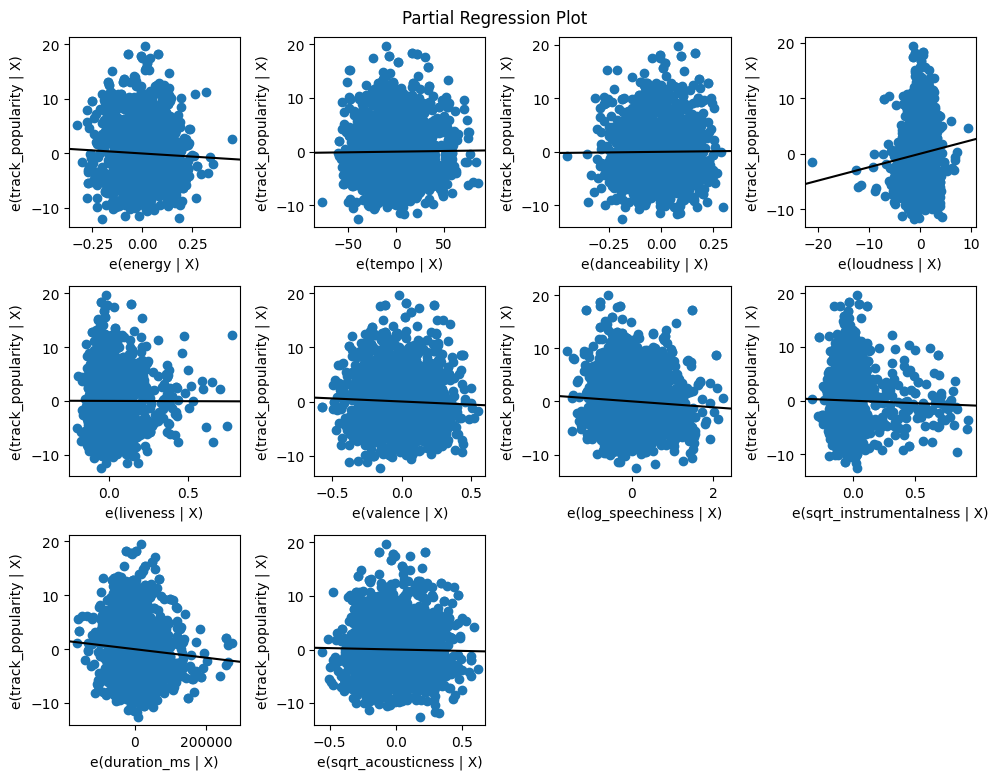

In [ ]:
# partial regression plots
fig = plt.figure(figsize = (10,10))
sm.graphics.plot_partregress_grid(results,
                                  exog_idx = ['energy', 'tempo', 'danceability', 'loudness', 'liveness', 'valence',
                                              'log_speechiness', 'sqrt_instrumentalness', 'duration_ms', 'sqrt_acousticness'],
                                  grid=(4,4),
                                  fig=fig)
fig.tight_layout()
plt.show()


#### Linearity
Because we don't see any S or U shapes in the plots above, it is safe to say that the linearity assumption is met, though loudness and instrumentalness do seem fairly clustered to one side of their respective graphs. One thing of note is that tempo, danceability, liveliness, instrumentalness, and acoustincess all have very flat lines, which could indicate that some of these variables may be unnecessary.

#### Independence

Each row comes from a different song, however we do know that certain artists have more songs on this list than others which could cause independence issues, because there could be some correlation between rows (each row is not giving us entirely new information), so this assupmtion may not be met.

<Figure size 400x400 with 0 Axes>

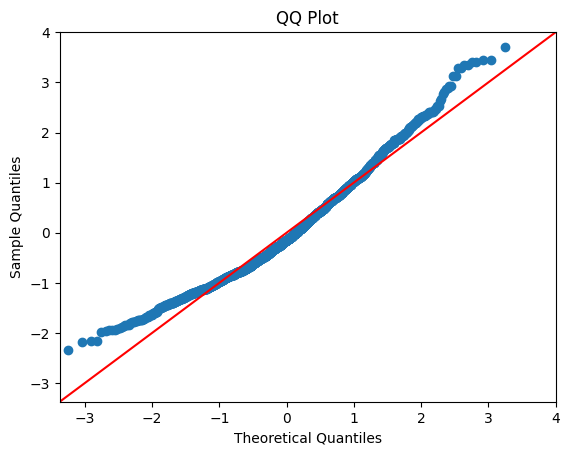

In [ ]:
# QQ plot
fig = plt.figure(figsize= (4,4))
sm.qqplot(df['residuals'],
          line = '45',
          fit = True)
plt.title('QQ Plot')
plt.show()

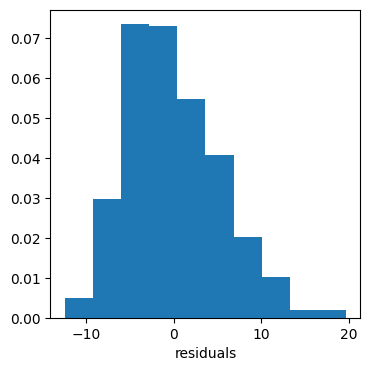

In [ ]:
# histogram
fig = plt.figure(figsize= (4,4))
plt.hist(df['residuals'],
         density = True,
         bins = 10)
plt.xlabel('residuals')
plt.show()

#### Normal Distribution

We can see that the observations in the Q-Q plot tend to veer away from the line pretty slightly around the -1 and 1 theoretical quantiles. Additionally, in our histogram we can see that there appear to be a slight right skew. Overall, it does look fairly good, so we'll say this assumption is met.

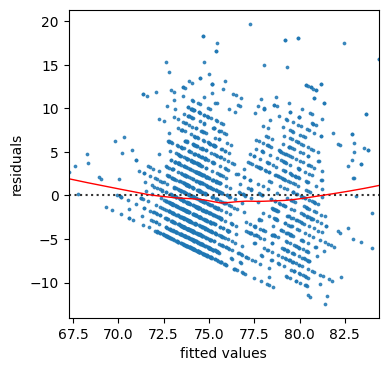

In [ ]:
# residuals vs fitted vals

fit = plt.figure(figsize= (4,4))
sns.residplot(x = df['fitted_vals'],
            y = df['residuals'],
            lowess = True,
            scatter_kws = {'s':3},
            line_kws = {'color':'red', 'lw':1})
plt.xlabel('fitted values')
plt.ylabel('residuals')
plt.show()

#### Equal constant variance

There doesn't appear to be any sort of cone or funnel shape, which is what we want. The lines do indicate we have some non-continuous variables, which we already knew. The shape of our red line is mostly flat but may be of note. In regards to variance, we will say this assumption is met.

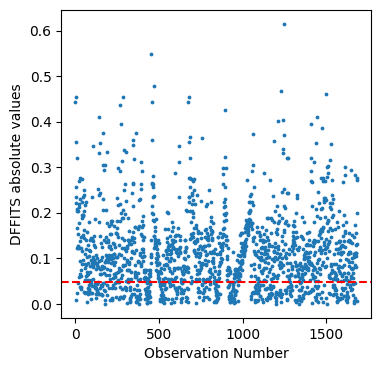

In [ ]:
# DFFITS
df['dffits'] = results.get_influence().dffits[0]

fix, ax = plt.subplots(figsize = (4,4))
ax.set_ylabel('DFFITS absolute values')
ax.set_xlabel('Observation Number')

ax.scatter(df.index,
           np.abs(df['dffits']),
           s = 3)
ax.axhline(y = 2/np.sqrt(len(df)), color = 'red', linestyle = 'dashed')

y_cutoff_dffits = 1 # Set arbitralily ased on results
outliers_dffits = df_dummy[np.abs(df['dffits']) > y_cutoff_dffits]
for i in outliers_dffits.index:
    ax.annotate(str(i), (i, np.abs(df['dffits'][i])))

plt.show()

#### All observations are described (No influential points)

While there are many observations above the red line, there are no observations that are dramatically far away from others. This observation is met.


#### Additional Predictor variables are not required

It is very possible that there are other predictor variables that could indicate track popularity, but in regards to information about the songs themselves, the dataset we have is very thorough, and as such, we will say that this assumption is met.

In [ ]:
# Variance inflation factors (VIF)
super_vifs = pd.DataFrame()
super_vifs['Feature'] = X.columns[1:]
super_vifs['VIF'] = [vif(X, i) for i in range(1, len(X.columns))]

print("Max =", super_vifs['VIF'].max())
print("Mean =", np.mean(super_vifs['VIF']))
super_vifs

Max = 18.773578332503583
Mean = 2.8761827262666286


,Feature,VIF
0,energy,3.306136
1,tempo,1.083992
2,danceability,1.944913
3,loudness,2.894672
4,liveness,1.064311
5,valence,1.510426
6,mode,1.148031
7,duration_ms,1.207385
8,log_speechiness,1.549808
9,sqrt_acousticness,1.831735


#### Multicollinearity

Time_signature_4 and 3 have VIF values higher than 10, but not by a super huge amount. This means that it is likely that our other variables can do a decent job of describing time_signature without including that as a variable at all. However, the average is not much higher than 1, so we will say that this assumption is met.

### Perform Necessary Transformations

Once we made sure that all of our variables are appropriately accounted for (ex: categorical variables like key and time signature are represented as cateogrical variables), all of our assumptions were met, so doing additional transformations was unnecessary.

# DA 2.4

Variable selection- Sequential Replacement. Because we have enough variables, the "best subsets" method would take too long compared to the significance of this project. Sequential replacement will help us find a more accurate model than forward or backward selection because it allows variables to enter or exit the model again if it improves it.

In [ ]:
# create function for plotting
def plot_model_selection_1se(selection_result, figsize = (8, 5)):
    """
    Plot model selection performance vs number of features
    using the 1-SE rule.

    Parameters
    ----------
    selection_result : object
        Must have method get_metric_dict() returning a dictionary
        with keys including:
            - "feature_names"
            - "avg_score"
            - "std_err"

    figsize : tuple
        Figure size for plot.
    """

    # Dictionary with key-value pairs
    # Key is an ID number for the subset
    # Value holds things like the number of variables in the subset, PMSE values, SD, etc.
    metric_dict = selection_result.get_metric_dict()

    # Convert metric_dict to a data frame (one row per subset)
    # orient = "index" tells python to use the keys as row names in the data frame
    results_df = pd.DataFrame.from_dict(metric_dict, orient="index")

    # number of features in each subset
    results_df["k"] = results_df["feature_names"].apply(len)

    # bounds for uncertainty
    results_df["upper"] = results_df["avg_score"] + results_df["std_err"]
    results_df["lower"] = results_df["avg_score"] - results_df["std_err"]

    # best subset within each k (max avg_score because it's negative MSE)
    best_by_k = (
        results_df.sort_values("avg_score", ascending=False)
        .groupby("k", as_index=False)
        .head(1)
        .sort_values("k")
    )

    # 1-SE rule: choose the smallest k whose performance is within 1 SE of the best
    best_row = best_by_k.loc[best_by_k["avg_score"].idxmax()]
    threshold = best_row["avg_score"] - best_row["std_err"]   # within 1 SE of best (higher is better)

    k_1se = best_by_k.loc[best_by_k["avg_score"] >= threshold, "k"].min()
    row_1se = best_by_k[best_by_k["k"] == k_1se].iloc[0]

    plt.figure(figsize=figsize)
    plt.fill_between(best_by_k["k"], best_by_k["lower"], best_by_k["upper"], alpha=0.2, lw=1)
    plt.plot(best_by_k["k"], best_by_k["avg_score"], marker="o")
    plt.axvline(row_1se["k"], linestyle="--")
    plt.xlabel("Number of Features")
    plt.ylabel("Negative PMSE ± SE")
    plt.grid(alpha=0.5)
    plt.xticks(ticks=best_by_k["k"], labels=best_by_k["k"])
    plt.show()

In [ ]:
y = df['track_popularity']
X = df_dummy.drop('track_popularity', axis = 1)

In [ ]:
print(X.columns)

Index(['energy', 'tempo', 'danceability', 'loudness', 'liveness', 'valence',
       'mode', 'duration_ms', 'log_speechiness', 'sqrt_acousticness',
       'sqrt_instrumentalness', 'playlist_genre_clean_classical',
       'playlist_genre_clean_electronic',
       'playlist_genre_clean_folk / indie / country',
       'playlist_genre_clean_hip-hop', 'playlist_genre_clean_international',
       'playlist_genre_clean_pop',
       'playlist_genre_clean_r&b / soul / blues / jazz',
       'playlist_genre_clean_rock / metal / punk', 'time_signature_3',
       'time_signature_4', 'time_signature_5', 'key_1', 'key_2', 'key_3',
       'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10',
       'key_11'],
      dtype='object')


In [ ]:
feature_groups = [[0],[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11], [12, 13, 14, 15, 16, 17, 18, 19], [20,21, 22], [23,24,25,26,27,28,29,30,31,32]]

In [ ]:
# Perform sequential replacement
seq_rep_selection = SFS(LinearRegression(fit_intercept = True),
                       k_features = (1, len(feature_groups)),  # defined above
                       forward = True,
                       floating = True,
                       scoring = 'neg_mean_squared_error',
                       feature_groups = feature_groups,  # defined above
                       cv = 5)

seq_rep = seq_rep_selection.fit(X, y)

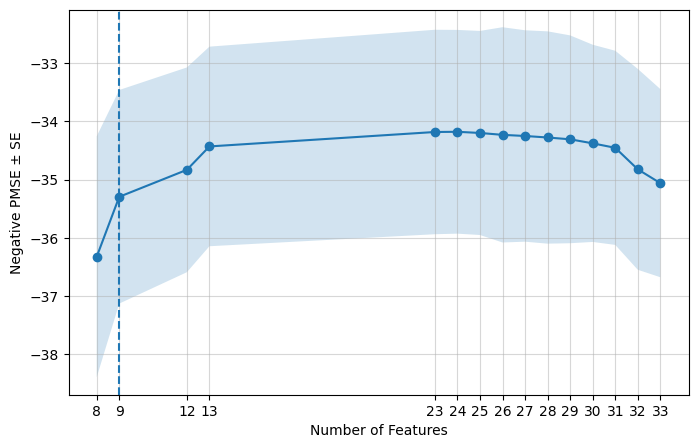

In [ ]:
plot_model_selection_1se(seq_rep)

In [ ]:
seq_rep_dict = seq_rep_selection.get_metric_dict()
seq_rep_df = pd.DataFrame.from_dict(seq_rep_dict, orient = 'index')

seq_rep_df['n_features'] = seq_rep_df['feature_names'].apply(len)

seq_rep_min_k = 1
seq_rep_max_k = 10  # max vars

seq_rep_df_table = seq_rep_df[(seq_rep_df['n_features'] >= seq_rep_min_k) & (seq_rep_df['n_features'] <= seq_rep_max_k)].copy()

seq_rep_df_table = seq_rep_df_table.sort_values('avg_score', ascending = False)

pd.set_option('display.max_colwidth', None)
print(seq_rep_df_table[['feature_names', 'avg_score']])
pd.reset_option('display.max_colwidth')

                                                                                                                                                                                                                                                                                      feature_names  \
2  (loudness, playlist_genre_clean_electronic, playlist_genre_clean_folk / indie / country, playlist_genre_clean_hip-hop, playlist_genre_clean_international, playlist_genre_clean_pop, playlist_genre_clean_r&b / soul / blues / jazz, playlist_genre_clean_rock / metal / punk, time_signature_3)   
1            (playlist_genre_clean_electronic, playlist_genre_clean_folk / indie / country, playlist_genre_clean_hip-hop, playlist_genre_clean_international, playlist_genre_clean_pop, playlist_genre_clean_r&b / soul / blues / jazz, playlist_genre_clean_rock / metal / punk, time_signature_3)   

   avg_score  
2 -35.295911  
1 -36.325774  


Based on the stepwise method, our best model has 9 features, which contain many parameters that pertain to playlist_genre categories, and includes time_signature_3. A similarly scored and larger model also includes an additional playlist_genre.

Shrinkage method- LASSO

In [ ]:
y_vec = df['track_popularity']
feature_names = X.columns.to_list()

In [ ]:
pipe_gl = make_pipeline(
    StandardScaler(),  # standardize predictors
    GroupLasso(
        groups = feature_groups,
        alpha = 1.0,  # equivalent to lambda, a placeholder that will later be tuned by CV
        fit_intercept = True  # add an intercept since feature_groups doesn't have one (and shouldn't)
    )
)

In [ ]:
# Takes about one minute to run
# Create our own cross-validation since GroupLassoCV doesn't exist
alpha_grid = np.logspace(-4, 4, 100)  # values of alpha/lambda to try, YOU alter this as needed based on the plot

gscv = GridSearchCV(
    estimator = pipe_gl,  # use the pipe above with GroupLasso
    param_grid = {"grouplasso__alpha": alpha_grid},  # "grouplasso" name comes from make_pipeline
    scoring = "neg_mean_squared_error",  # negative PMSE
    cv = 5,  # 5-fold cross-validation
    n_jobs = -1,  # run this in parallel using *all* cores
    refit = False  # we'll refit this manually after the 1-SE selection
)

gscv.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('grouplasso',
                                        GroupLasso(groups=[[0], [1], [2], [3],
                                                           [4], [5], [6], [7],
                                                           [8], [9], [10], [11],
                                                           [12, 13, 14, 15, 16,
                                                            17, 18, 19],
                                                           [20, 21, 22],
                                                           [23, 24, 25, 26, 27,
                                                            28, 29, 30, 31,
                                                            32]]))]),
             n_jobs=-1,
             param_grid={'grouplasso__alpha': array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10...
       1.38488637e+02, 1.66810054e+02, 2.00923300e+02, 2.42012826e+02,
       2.91505306e+02, 3.51119173e+02, 4.22924287e+02, 5.09413801e+02,
       6.13590727e+02, 7.39072203e+02, 8.90215085e+02, 1.07226722e+03,
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04])},
             refit=False, scoring='neg_mean_squared_error')

In [ ]:
cv_res = pd.DataFrame(gscv.cv_results_)
cv_res["mean_mse"] = -cv_res["mean_test_score"]  # positive MSE
cv_res["se_mse"] = cv_res["std_test_score"] / np.sqrt(gscv.cv)  # standard error across folds
cv_res["alpha"] = cv_res["param_grouplasso__alpha"].astype(float)

# 1-SE rule: largest alpha within 1 SE of the minimum MSE
best_idx = cv_res["mean_mse"].idxmin()
best_mse = cv_res.loc[best_idx, "mean_mse"]
best_se  = cv_res.loc[best_idx, "se_mse"]
threshold = best_mse + best_se

alpha_1se = cv_res.loc[cv_res["mean_mse"] <= threshold, "alpha"].max()
alpha_min = cv_res.loc[best_idx, "alpha"]

print("Minimum-rule alpha:", alpha_min)
print("1-SE-rule alpha:", alpha_1se)
print("Best mean CV MSE:", best_mse)

Minimum-rule alpha: 0.24770763559917114
1-SE-rule alpha: 0.9111627561154896
Best mean CV MSE: 33.27982579045565


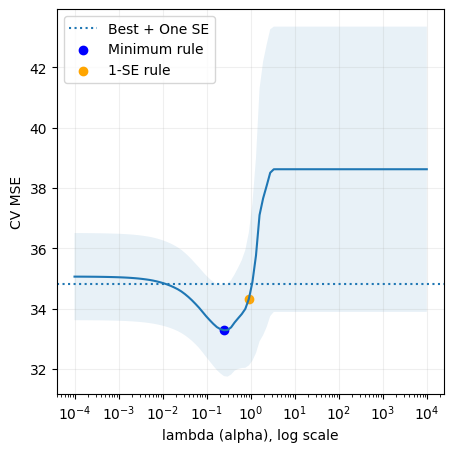

In [ ]:
plot_df = cv_res.sort_values("alpha")

plt.figure(figsize = (5, 5))
plt.plot(plot_df["alpha"],
         plot_df["mean_mse"])
plt.fill_between(
    plot_df["alpha"],
    plot_df["mean_mse"] - plot_df["se_mse"],
    plot_df["mean_mse"] + plot_df["se_mse"],
    alpha = 0.1
)
plt.axhline(threshold,
            linestyle = "dotted",
            label = "Best + One SE")
plt.scatter([alpha_min],
            [best_mse],
            color = "blue",
            label = "Minimum rule")
plt.scatter([alpha_1se],
            [plot_df.loc[plot_df["alpha"] == alpha_1se, "mean_mse"].values[0]],
            color = "orange",
            label = "1-SE rule")
plt.xscale("log")
plt.xlabel("lambda (alpha), log scale")
plt.ylabel("CV MSE")
plt.legend()
plt.grid(alpha = 0.2)
plt.show()

In [ ]:
# Fit final model at alpha_1se
final = make_pipeline(
    StandardScaler(),
    GroupLasso(
        groups = feature_groups,
        alpha = alpha_1se,
        fit_intercept = True,
    )
)
final.fit(X, y)

coefs = final.named_steps["grouplasso"].coef_.ravel()
coef_table = (
    pd.DataFrame({"feature": X.columns, "coef": coefs})
      .assign(abs_coef = lambda d: d["coef"].abs())
      .sort_values("abs_coef", ascending = False)
      .drop(columns = "abs_coef")
)
print(coef_table)

                                           feature      coef
16                        playlist_genre_clean_pop  1.092920
19                                time_signature_3  0.500586
15              playlist_genre_clean_international -0.487269
18        playlist_genre_clean_rock / metal / punk -0.440594
14                    playlist_genre_clean_hip-hop -0.399307
12                 playlist_genre_clean_electronic -0.360255
17  playlist_genre_clean_r&b / soul / blues / jazz -0.264902
13     playlist_genre_clean_folk / indie / country -0.144588
0                                           energy  0.000000
8                                  log_speechiness  0.000000
7                                      duration_ms  0.000000
6                                             mode  0.000000
5                                          valence  0.000000
4                                         liveness  0.000000
1                                            tempo  0.000000
3                       

The LASSO suggested model suggested the exact same variables as our stepwise method, which is usally a pretty good sign in regards to our model.

## Summary

Both of our variable selection methods suggested the same variables, which is usually a good sign. It reaffirms that we don't have many issues with multicollinearity, and that there aren't many competing models for us to consider. The variables suggested for us to use were: playlist_genre_clean_pop, time_signature_3, playlist_genre_clean_international, playlist_genre_clean_rock, playlist_genre_clean_hip-hop, playlist_genre_clean_electronic, playlist_genre_clean_r&b, and playlist_genre_clean_folk.

# DA2.5

#### Model Assessment

In [ ]:
# making df with variables we want to include
df_final = df_dummy[['track_popularity', 'playlist_genre_clean_pop', 'time_signature_3', 'playlist_genre_clean_international',
                    'playlist_genre_clean_rock / metal / punk', 'playlist_genre_clean_hip-hop', 'playlist_genre_clean_electronic',
                     'playlist_genre_clean_r&b / soul / blues / jazz', 'playlist_genre_clean_folk / indie / country']]

In [ ]:
df_final.head()

,track_popularity,playlist_genre_clean_pop,time_signature_3,playlist_genre_clean_international,playlist_genre_clean_rock / metal / punk,playlist_genre_clean_hip-hop,playlist_genre_clean_electronic,playlist_genre_clean_r&b / soul / blues / jazz,playlist_genre_clean_folk / indie / country
0,100,1,1,0,0,0,0,0,0
1,97,1,0,0,0,0,0,0,0
2,93,1,0,0,0,0,0,0,0
3,81,1,0,0,0,0,0,0,0
4,98,1,0,0,0,0,0,0,0


In [ ]:
# refitting final model with selected variables
y = df_final['track_popularity']
X = df_final.drop('track_popularity', axis=1)
X = sm.add_constant(X)
model = sm.OLS(y, X)
results_final = model.fit()

df_final['residuals_final'] = results_final.resid
df_final['fitted_vals_final'] = results_final.fittedvalues
df_final.head()

print(results_final.summary())

                            OLS Regression Results                            
Dep. Variable:       track_popularity   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     44.38
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           6.22e-65
Time:                        05:13:10   Log-Likelihood:                -5260.0
No. Observations:                1686   AIC:                         1.054e+04
Df Residuals:                    1677   BIC:                         1.059e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/tmp/ipykernel_25516/1060332949.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['residuals_final'] = results_final.resid
/tmp/ipykernel_25516/1060332949.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['fitted_vals_final'] = results_final.fittedvalues


In [ ]:
# R^2
print("R^2:", round(results_final.rsquared, 4))

R^2: 0.1747


$R^2$ Interpretation: 17.47% of the variation in Track Popularity is explained by the other variables in the model. While this is a low number, the original model with all variables we could reasonably include only had an R^2 value of 22.1%, so the current model is only a little worse but uses significantly less variables.

In [ ]:
# p value from f test
print("The test statistic for the F-test is",
      round(results_final.fvalue, 2),
      "and the corresponding p-value is",
      results_final.f_pvalue)

The test statistic for the F-test is 44.38 and the corresponding p-value is 6.21901730987508e-65


P value interpretation: Our P-value is less than 0.05, meaning we fail to reject the null hypothesis, and our results are statistically significant, meaning there is a relationship between track popularity and if it has a time signature of 3/4 and if it has a playlist genre of pop, international, rock/similar, hip hop, electronic, R&B/similar, or country/similar.

In [ ]:
# RMSE
mse = np.sum((df_final['track_popularity'] - df_final['fitted_vals_final']) ** 2) / (len(df_dummy) - 2)
rmse = np.sqrt(mse)
print(rmse)

5.481827434815551


In [ ]:
# print range of values for
col = df_final['track_popularity']

print("Maximum Value:", col.max())
print("Minimum Value:", col.min())
print("Range:", col.max()-col.min())


Maximum Value: 100
Minimum Value: 68
Range: 32


RMSE Interpretation: On average, the difference between predicted and actual track popularity score 5.4. Given our range of 68-100, the model has a medium sized prediction error. It isn't small and precise as we would like, but it is small enough to help us narrow down the general popularity score of a song.

In [ ]:
# MAE
mae = np.sum(np.abs(df_final['track_popularity'] - df_final['fitted_vals_final'])) / (len(df) - 2)
print(mae)

4.440936633256683


MAE Interpretation: The average absolute difference between observed and predicted track popularity 4.4. Given our range of 68-100, this is a medium-small prediction error. Again, it isn't small and precise as we would like, but it is small enough to help us narrow down the general popularity score of a song.

#### Model Inference

CIs for all statistically significant slopes

In [ ]:
ci_df = pd.DataFrame({
    "lower": results_final.conf_int()[0],
    "upper": results_final.conf_int()[1],
    "pval":  results_final.pvalues
})

ci = ci_df[ci_df['pval'] < 0.05].drop(columns="pval")
print("\nCIs for statistically significant slopes:")
print(ci)




CIs for statistically significant slopes:
                                                    lower      upper
const                                           76.409297  78.067589
playlist_genre_clean_pop                         1.571683   3.569746
time_signature_3                                 2.029111   4.365561
playlist_genre_clean_international              -4.225876  -2.191286
playlist_genre_clean_rock / metal / punk        -4.044229  -2.003707
playlist_genre_clean_hip-hop                    -4.197393  -2.009842
playlist_genre_clean_electronic                 -4.513553  -2.090288
playlist_genre_clean_r&b / soul / blues / jazz  -4.573863  -1.849309
playlist_genre_clean_folk / indie / country     -4.764891  -0.981729


Interpretations:

* Const/Intercept: We are 95% confident a song in the background/ambient genre with a time signature that is not 3/4 will have a popularity score between 76.409 to 78.06
* playlist_genre_clean_pop: We are 95% confident if the playlist genre is pop, track_popularity will be between 1.5717 and 3.5697 more than a song in the background/ambient genre
* time_signature_3: We are 95% confident if the time signature is 3/4, track_popularity will be between 2.0291 and 4.3656 more than other time signatures
* Playlist_genre_international: We are 95% confident if the playlist genre is international, track_popularity will be between 2.1913 and 4.2259 less than a song in the background/ambient genre
* Playlist_genre_rock_group: We are 95% confident if the playlist genre is rock, metal, or punk, track_popularity will be between 2.0037 and 4.0442 less than a song in the background/ambient genre
* Playlist_genre_hip-hop: If the playlist genre is hip-hop, track_popularity will be between 2.0098 and 4.1973 less than a song in the background/ambient genre
* Playlist_genre_electronic: We are 95% confident if the playlist genre is country, track_popularity will be between 2.0903 and 4.5136 less than a song in the background/ambient genre
* Playlist_genre_r&b_group: We are 95% confident if the playlist genre is r&b, soul, blues, or jazz, track_popularity will be between 1.8493 and 4.5638 less than a song in the background/ambient genre
* Playlist_genre_folk_group: We are 95% confident if the playlist genre is hip-hop, track_popularity will be between 0.9817 and 4.7649 less than a song in the background/ambient genre




Hypothesis Tests for all Slopes

For all significant predictors (all variables listed above with their confidence intervals), there is sufficient evidence that each of them have a real linear relationship with track_popularity after controlling for all other variables in the model. We can see this because all the confidence intervals listed above do not contain 0.

CI for the mean of Y

In [ ]:
x_mean = [
    1,           # Intercept
    0,           # playlist_genre_clean_pop
    1,           # time_signature_3
    1,           # playlist_genre_clean_international
    0,           # playlist_genre_clean_rock / metal / punk
    0,           # playlist_genre_clean_hip-hop
    0,           # playlist_genre_clean_electronic
    0,           # playlist_genre_clean_r&b / soul / blues / jazz
    0,           # playlist_genre_clean_folk / indie / country
]

pred_mean = results_final.get_prediction(x_mean)
ci_mean_frame = pred_mean.summary_frame(alpha=0.05)

# Back-transform: since y = 1/popularity, popularity = 1/y
ci_mean_bt = ci_mean_frame[["mean", "mean_ci_upper", "mean_ci_lower"]]
print("\nCI for mean of Y:")
print(ci_mean_bt)


CI for mean of Y:
        mean  mean_ci_upper  mean_ci_lower
0  77.227197      78.485877      75.968518


For international songs in 3/4 time, we are 95% confident
that, on average, track popularity falls between 75.9685 and 78.4859.

Prediction interval for a new observation

In [ ]:
pred_new = results_final.get_prediction(x_mean)
pi_frame = pred_new.summary_frame(alpha=0.05)

# Back-transform
pi_bt = pi_frame[["mean", "obs_ci_upper", "obs_ci_lower"]]
print("\nPrediction interval for new observation:")
print(pi_bt)


Prediction interval for new observation:
        mean  obs_ci_upper  obs_ci_lower
0  77.227197      88.07483     66.379565


For international songs in 3/4 time, we are 95% confident
that track popularity will fall between 66.3796 and 88.0748.

### Interactions

In [ ]:
df_final.columns

Index(['track_popularity', 'playlist_genre_clean_pop', 'time_signature_3',
       'playlist_genre_clean_international',
       'playlist_genre_clean_rock / metal / punk',
       'playlist_genre_clean_hip-hop', 'playlist_genre_clean_electronic',
       'playlist_genre_clean_r&b / soul / blues / jazz',
       'playlist_genre_clean_folk / indie / country', 'residuals_final',
       'fitted_vals_final'],
      dtype='object')

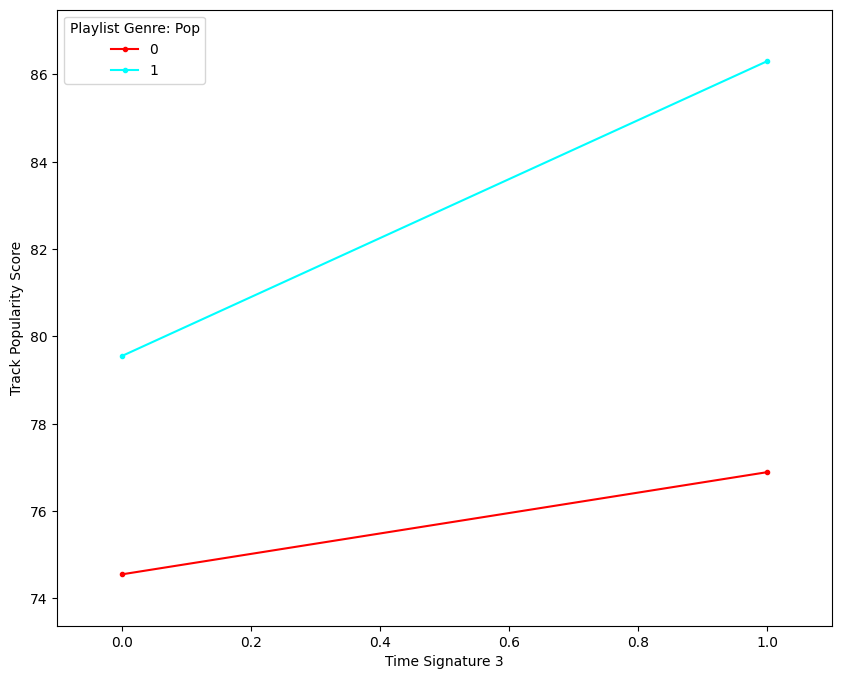

In [ ]:
# interaction plot
fig, ax = plt.subplots(figsize=(10,8))
fig = interaction_plot(x = df_final['time_signature_3'],
                      trace = df_final['playlist_genre_clean_pop'],
                      response = df_final['track_popularity'],
                      ax = ax)
ax.set_xlabel('Time Signature 3')
ax.set_ylabel('Track Popularity Score')
ax.legend(title = 'Playlist Genre: Pop')

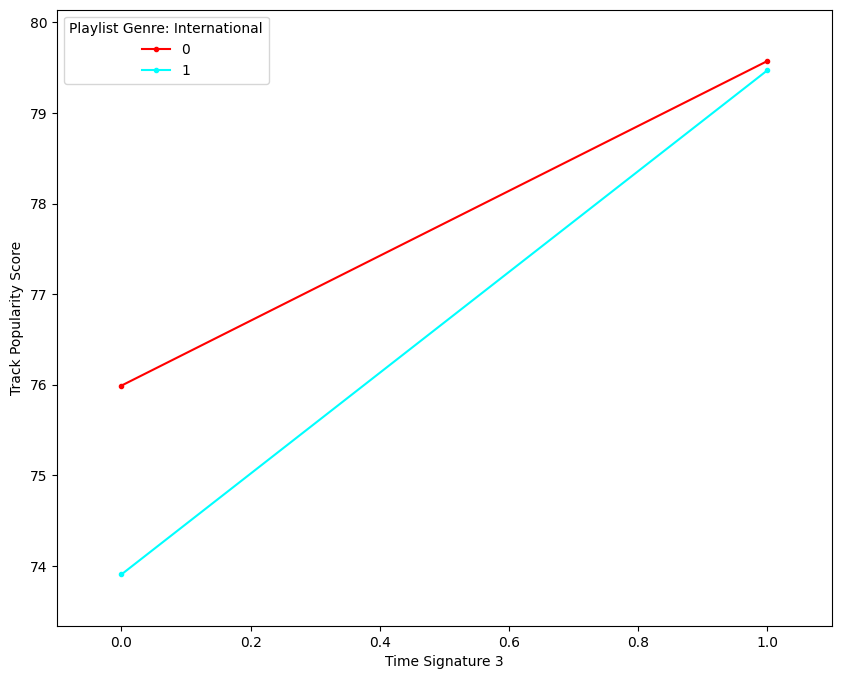

In [ ]:
# interaction plot
fig, ax = plt.subplots(figsize=(10,8))
fig = interaction_plot(x = df_final['time_signature_3'],
                      trace = df_final['playlist_genre_clean_international'],
                      response = df_final['track_popularity'],
                      ax = ax)
ax.set_xlabel('Time Signature 3')
ax.set_ylabel('Track Popularity Score')
ax.legend(title = 'Playlist Genre: International')

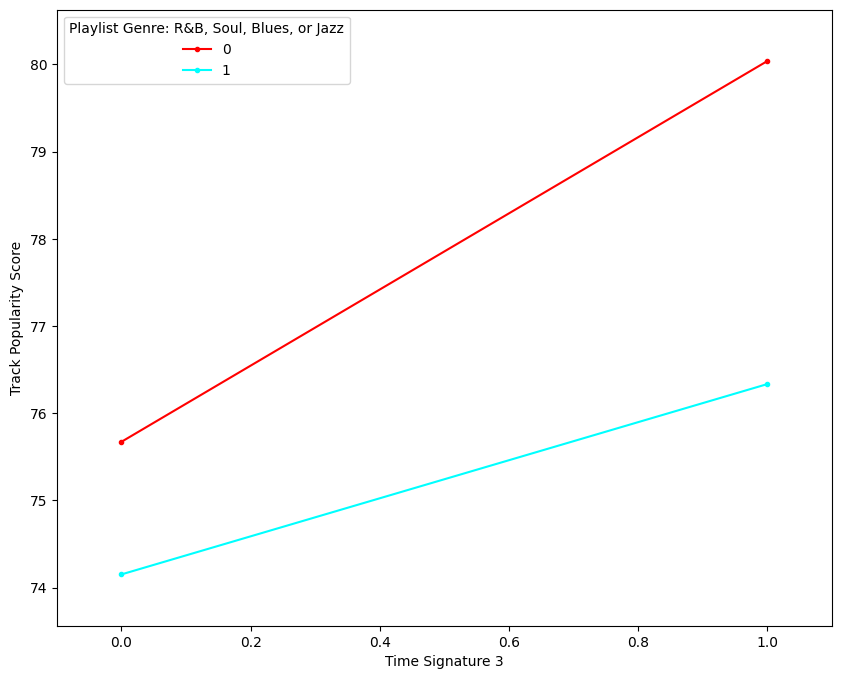

In [ ]:
# interaction plot
fig, ax = plt.subplots(figsize=(10,8))
fig = interaction_plot(x = df_final['time_signature_3'],
                      trace = df_final['playlist_genre_clean_r&b / soul / blues / jazz'],
                      response = df_final['track_popularity'],
                      ax = ax)
ax.set_xlabel('Time Signature 3')
ax.set_ylabel('Track Popularity Score')
ax.legend(title = 'Playlist Genre: R&B, Soul, Blues, or Jazz')

While comparing a time signature of 3 to three different playlist genres, we noticed some slight interactions. However, none of them are large or significant enough to make a big difference in our model so we are not going to include them at the risk of adding more noise to the model.

### Testing model with interaction

In [ ]:
df_final_int = df_final[['track_popularity', 'playlist_genre_clean_pop', 'time_signature_3', 'playlist_genre_clean_international',
                    'playlist_genre_clean_rock / metal / punk', 'playlist_genre_clean_hip-hop', 'playlist_genre_clean_electronic',
                     'playlist_genre_clean_r&b / soul / blues / jazz', 'playlist_genre_clean_folk / indie / country']]

In [ ]:
# making interaction cols
df_final_int['TS3_International'] = df_final_int['time_signature_3'] * df_final_int['playlist_genre_clean_international']
df_final_int.head()

/tmp/ipykernel_25516/846445080.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final_int['TS3_International'] = df_final_int['time_signature_3'] * df_final_int['playlist_genre_clean_international']


,track_popularity,playlist_genre_clean_pop,time_signature_3,playlist_genre_clean_international,playlist_genre_clean_rock / metal / punk,playlist_genre_clean_hip-hop,playlist_genre_clean_electronic,playlist_genre_clean_r&b / soul / blues / jazz,playlist_genre_clean_folk / indie / country,TS3_International
0,100,1,1,0,0,0,0,0,0,0
1,97,1,0,0,0,0,0,0,0,0
2,93,1,0,0,0,0,0,0,0,0
3,81,1,0,0,0,0,0,0,0,0
4,98,1,0,0,0,0,0,0,0,0


In [ ]:
# refitting final model with selected variables
y = df_final_int['track_popularity']
X = df_final_int.drop('track_popularity', axis=1)
X = sm.add_constant(X)
model_int = sm.OLS(y, X)
results_final_int = model_int.fit()

df_final_int['residuals_final'] = results_final_int.resid
df_final_int['fitted_vals_final'] = results_final_int.fittedvalues
df_final_int.head()

print(results_final_int.summary())

                            OLS Regression Results                            
Dep. Variable:       track_popularity   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     39.93
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           7.01e-65
Time:                        05:13:11   Log-Likelihood:                -5258.1
No. Observations:                1686   AIC:                         1.054e+04
Df Residuals:                    1676   BIC:                         1.059e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

After testing the model with the interaction with the most possibility of being useful, we saw that our R^2 went up from 17.5% to 17.7%. Even though it was an increased value, it is a negligable amount. We are not going to re-calculate other interpretations and metrics with the interaction model because of this.

## Conclusion

Each row in this dataset represents a different song from the 100 most popular songs on spotify (from a recent time period). We wanted to see if we could determine a song's popularity based on other variables, such as time signature, acousticness, loudness, etc.

From this analysis, we learned that genre, and a time signature of 3/4 have a statistically significant relationship to a track's popularity. The biggest factor was genre--if it was a pop song, it was generally more popular than songs from other genres. Additionally, a time signature of 3/4 also tended to have a positive impact on track popularity.

An important limitation or caveat is that we did not meet the assumption that our data was not related. Because several songs come from the same artists, our data is not truly independent, which is something to note when looking at this analysis. Additionally, there may be more variables that could predict track popularity than what we had in our dataset.

(testing)

In [ ]:
print('testing for printing to pdf')

testing for printing to pdf)
